# <span style="color:blue"> EDA of external data </span>

In [243]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [244]:
weather= pd.read_csv('E:/ProjetBI/extern_data/combined_weather_data.csv')
weather["Temperature"][0]="14 C/23 C"
weather['Temperature'][1]="11 C/18 C"
display(weather.head())
a=weather['Temperature'].str.extract(r'(\d+) C/(\d+) C').astype(float)
weather["Temperature"]=a[0]/2 +a[1]/2
display(weather.head())
weather_selected = weather.iloc[:, :4]
display(weather_selected.head())
weather_selected.to_csv('E:/ProjetBI/extern_data/weather.csv', index=False)
weather=pd.read_csv('E:/ProjetBI/extern_data/weather.csv')
display(weather.head())

,Date,Temperature,precipitation,avis,precipitations,Precipitation,Avis
0,01/04/2023,14 C/23 C,0.1mm,favorable,NaN,NaN,NaN
1,02/04/2023,11 C/18 C,0.2mm,favorable,NaN,NaN,NaN
2,03/04/2023,12 C/18 C,1.1mm,correct,NaN,NaN,NaN
3,04/04/2023,11 C/19 C,0mm,favorable,NaN,NaN,NaN
4,05/04/2023,11 C/14 C,1mm,defavorable,NaN,NaN,NaN


,Date,Temperature,precipitation,avis,precipitations,Precipitation,Avis
0,01/04/2023,18.5,0.1mm,favorable,NaN,NaN,NaN
1,02/04/2023,14.5,0.2mm,favorable,NaN,NaN,NaN
2,03/04/2023,15.0,1.1mm,correct,NaN,NaN,NaN
3,04/04/2023,15.0,0mm,favorable,NaN,NaN,NaN
4,05/04/2023,12.5,1mm,defavorable,NaN,NaN,NaN


,Date,Temperature,precipitation,avis
0,01/04/2023,18.5,0.1mm,favorable
1,02/04/2023,14.5,0.2mm,favorable
2,03/04/2023,15.0,1.1mm,correct
3,04/04/2023,15.0,0mm,favorable
4,05/04/2023,12.5,1mm,defavorable


,Date,Temperature,precipitation,avis
0,01/04/2023,18.5,0.1mm,favorable
1,02/04/2023,14.5,0.2mm,favorable
2,03/04/2023,15.0,1.1mm,correct
3,04/04/2023,15.0,0mm,favorable
4,05/04/2023,12.5,1mm,defavorable


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           244 non-null    datetime64[ns]
 1   Temperature    244 non-null    float64       
 2   precipitation  30 non-null     object        
 3   avis           61 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 7.8+ KB
None
                      Date  Temperature       avis
count                  244   244.000000  61.000000
mean   2023-07-31 12:00:00    23.661885   2.245902
min    2023-04-01 00:00:00    12.500000   0.000000
25%    2023-05-31 18:00:00    19.000000   2.000000
50%    2023-07-31 12:00:00    23.500000   2.000000
75%    2023-09-30 06:00:00    27.500000   3.000000
max    2023-11-30 00:00:00    37.500000   3.000000
std                    NaN     5.140357   0.698945
Date               0
Temperature        0
precipitation

,Date,Temperature,precipitation,avis
0,2023-04-01,18.5,0.1mm,2.0
1,2023-04-02,14.5,0.2mm,2.0
2,2023-04-03,15.0,1.1mm,1.0
3,2023-04-04,15.0,0mm,2.0
4,2023-04-05,12.5,1mm,0.0


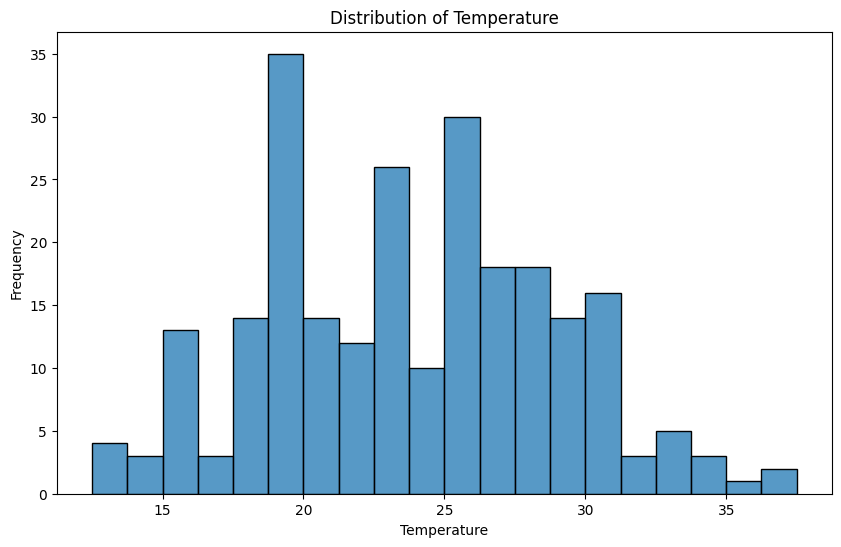

In [245]:
# Load the data
weather=pd.read_csv('E:/ProjetBI/extern_data/weather.csv')

# Define the mapping dictionary
mapping = {"ideal": 3, "favorable": 2, "correct": 1, "defavorable": 0}
# Apply the mapping to the "avis" column
weather['avis'] = weather['avis'].map(mapping)
weather['avis'].astype('float64')
weather["Date"]=pd.to_datetime(weather["Date"],format='%d/%m/%Y')
print(weather.info())
print(weather.describe())
# Check for missing values
print(weather.isnull().sum())
# Display the updated dataframe
display(weather.head())
# Visualize the distribution of temperature
plt.figure(figsize=(10, 6))
sns.histplot(data=weather, x='Temperature', bins=20)
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.show()


To understand the distribution of temperature across the seven months, we created a histogram. The histogram reveals that temperatures 20 and 26 degrees Celsius are the most frequent, while temperatures of 35 and 17 degrees Celsius are the least common.

This information provides valuable insights into the temperature patterns and can be used to make informed decisions in our project.



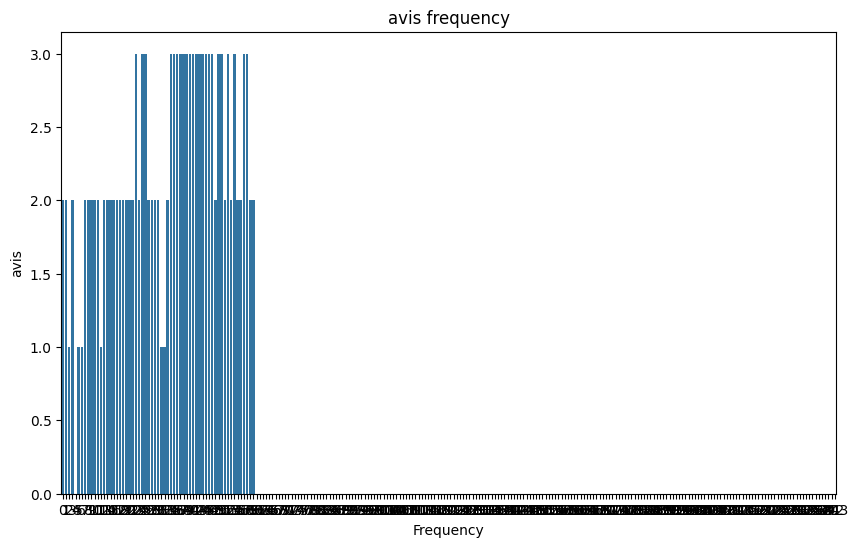

In [246]:
# Visualize the relationship between temperature and other variables
plt.figure(figsize=(10, 6))
sns.barplot(weather['avis'])
plt.xlabel('Frequency')
plt.ylabel('avis')
plt.title('avis frequency')
plt.show()

To visualize this distribution, we created a bar plot. The bar plot provides insights into the frequency of each "avis" category. 

From the bar plot, we observe that the "ideal" avis is the most common, while the "defavorable" avis is the least common. This information helps us understand the overall sentiment or perception associated with the dataset.

By analyzing the distribution of "avis," we can gain valuable insights into the opinions expressed and make informed decisions based on the feedback received.


In [247]:
# Calculate the correlation matrix
correlation_matrix = weather.corr()

# Create a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Weather Dataset')
plt.show()


ValueError: could not convert string to float: '0.1mm'

Upon analyzing the correlation heatmap, we observe a strong positive correlation between the "avis" and the "temperature" variables. This suggests that as the temperature increases, the "avis" tends to be more favorable. Additionally, there is a noticeable correlation between the "avis" and the "date" variable, indicating that certain dates may have a higher frequency of favorable "avis" ratings.

However, we observe a weak correlation between the "precipitation" variable and the other columns. This implies that precipitation may not have a significant impact on the "avis" or other variables in the dataset.

By understanding these correlation patterns, we can gain valuable insights into the relationships between different variables and make informed decisions based on the data.


,Type,Category,1-day Admission,2-day Admission,3-day Admission,After 4pm Admission
0,Gate,Regular Ages 8-64,36.00,44.0,NaN,NaN
1,Gate,Youth Ages 3-7,19.88,27.0,NaN,NaN
2,Gate,Senior Ages 65+,19.88,27.0,NaN,NaN
3,Gate,Children Ages 2 & younger,0.00,0.0,NaN,NaN
4,Online,Regular Ages 8-64,36.00,41.0,NaN,NaN
5,Online,Youth Ages 3-7,19.88,25.0,NaN,NaN
6,Online,Senior Ages 65+,19.88,25.0,NaN,NaN
7,Online,Children Ages 2 & younger,0.00,0.0,NaN,NaN
8,Gate,Regular Ages 8-64,84.00,125.0,55.0,NaN
9,Gate,Youth Ages 3-7,54.00,78.0,44.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 68 non-null     object 
 1   Category             68 non-null     object 
 2   1-day Admission      68 non-null     float64
 3   2-day Admission      64 non-null     float64
 4   3-day Admission      40 non-null     float64
 5   After 4pm Admission  20 non-null     float64
dtypes: float64(4), object(2)
memory usage: 3.3+ KB
None
       1-day Admission  2-day Admission  3-day Admission  After 4pm Admission
count        68.000000         64.00000         40.00000            20.000000
mean         24.570588         33.43750         35.17500            20.850000
std          20.713254         29.04068         35.25576            14.900636
min           0.000000          0.00000          0.00000             0.000000
25%           0.000000         14.25000         14.

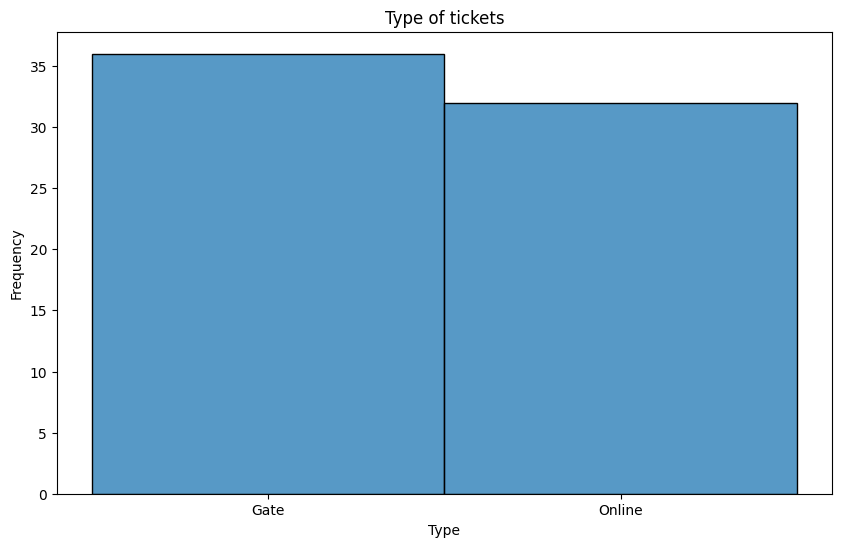

In [ ]:
ticket_p = pd.read_csv('E:/ProjetBI/extern_data/ticket_prices.csv', sep=';')

# Display the first few rows of the table
display(ticket_p.head(20))

# Check the data types and summary statistics of the columns
print(ticket_p.info())
print(ticket_p.describe())

# Check for missing values
print(ticket_p.isnull().sum())
# Visualize the distribution of ticket prices
plt.figure(figsize=(10, 6))
sns.histplot(data=ticket_p, x='Type')
plt.xlabel('Type')
plt.ylabel('Frequency')
plt.title('Type of tickets')
plt.show()


The bar plot provides valuable insights into the frequency of different ticket types. From the plot, we can observe that the "Gate" type of tickets dominates over the "Online" type. This information helps us understand the distribution of ticket types and can be used to make informed decisions in our analysis.


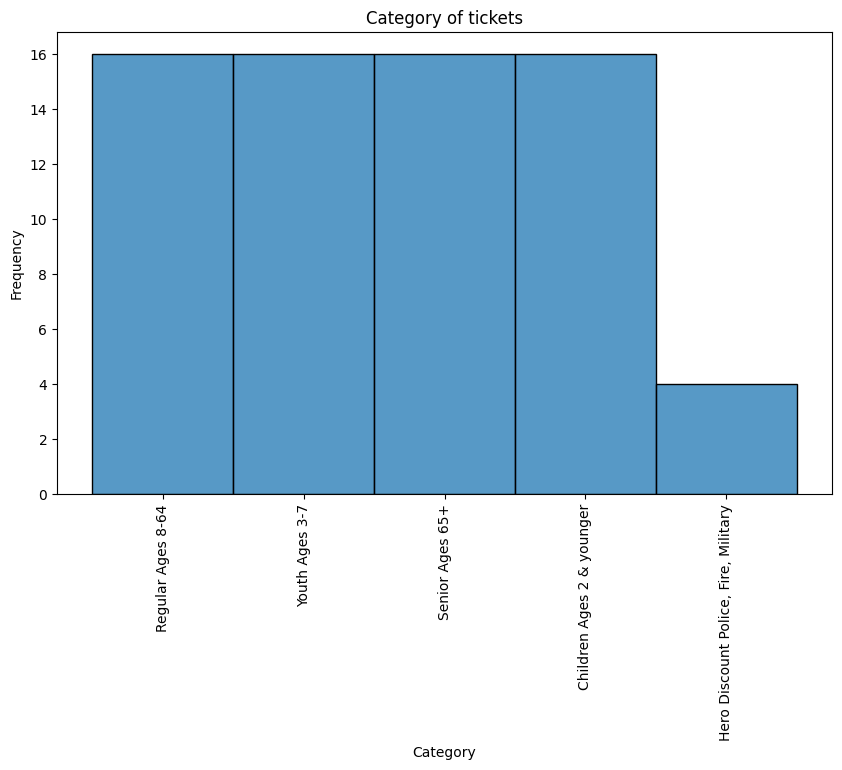

In [ ]:
# Visualize the distribution of ticket prices
plt.figure(figsize=(10, 6))
sns.histplot(data=ticket_p, x='Category')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.title('Category of tickets')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically
plt.show()

this bar plot shows as the frequency of each category , as we can see there are four major categories "regulart ages 8-64" , "youth ages 3-7" , "senior ages 65+" and "children ages 2 and younger"  

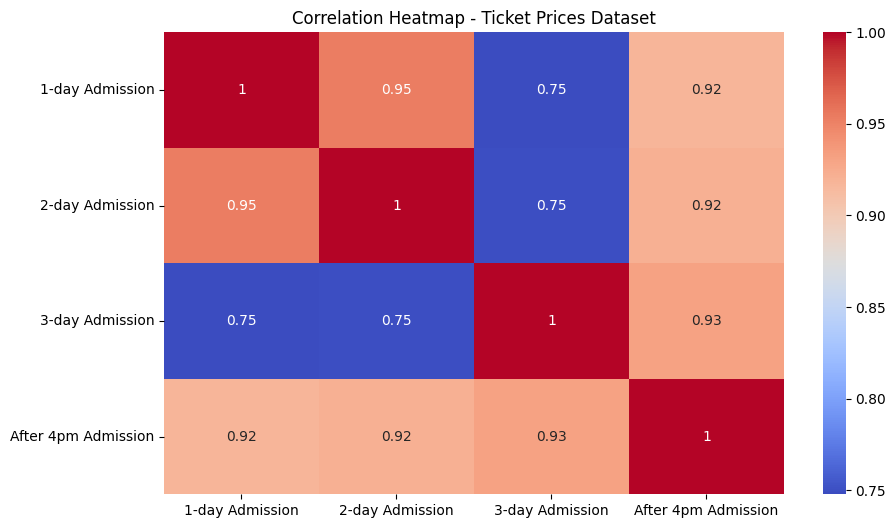

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(ticket_p.iloc[:, 2:].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Ticket Prices Dataset')
plt.show()


The correlation heatmap provides insights into the relationship between variables in the dataset. 

Upon analyzing the heatmap, we observe a strong positive correlation between the first and second day. However, the correlation decreases for the third day. This information suggests that there may be a stronger relationship between the first and second day compared to the third day.

By understanding the correlation patterns, we can gain valuable insights into the dataset and make informed decisions based on the relationships between variables.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Ride Name        59 non-null     object
 1   Attraction Type  59 non-null     object
 2   Minimum Height   55 non-null     object
dtypes: object(3)
memory usage: 1.5+ KB
None
         Ride Name Attraction Type Minimum Height
count           59              59             55
unique          59               4             12
top     Aruba Tuba          Family            48"
freq             1              18             12
Ride Name          0
Attraction Type    0
Minimum Height     4
dtype: int64


,Ride Name,Attraction Type,Minimum Height
0,Aruba Tuba,Family,42.0
1,Autobahn,Family,48.0
2,Bamboozler,Thrill,46.0
3,Beagle Brigade Airfield,Kids,36.0
4,Boomerang,Roller Coasters,48.0
5,Camp Bus,Kids,36.0
6,Captain Kidd's,Kids,NaN
7,Caribbean Cooler,Family,42.0
8,Castaway Cove,Family,NaN
9,Charlie Brown's Windup,Kids,36.0


59

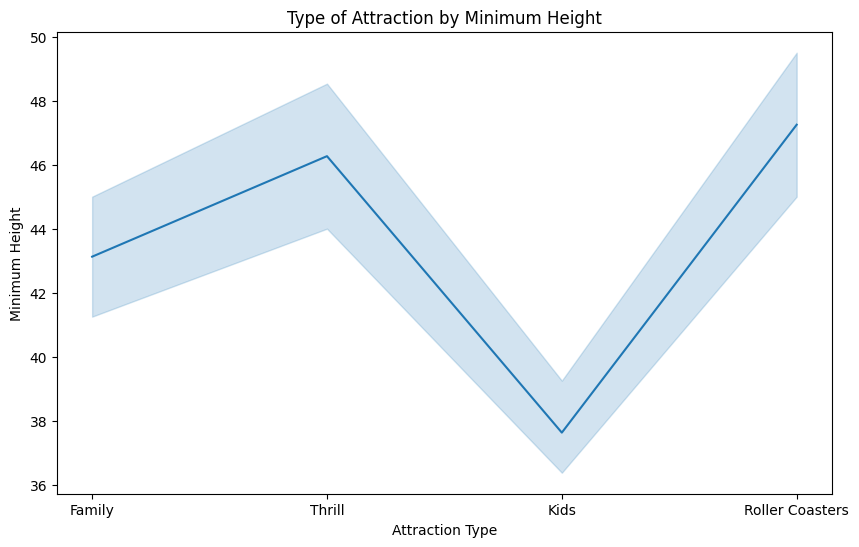

In [ ]:
ride = pd.read_csv('E:/ProjetBI/extern_data/rides.csv', sep=';')
# Check the data types and summary statistics of the columns
print(ride.info())
print(ride.describe())

# Check for missing values
print(ride.isnull().sum())
ride['Minimum Height'] = ride['Minimum Height'].str.extract(r'(/d+)').astype(float)
display(ride.head(30))
display(len(ride["Ride Name"].unique()))
# Visualize the distribution of ride durations
plt.figure(figsize=(10, 6))
sns.lineplot(data=ride, x='Attraction Type',y='Minimum Height')
plt.xlabel('Attraction Type')
plt.ylabel('Minimum Height')
plt.title('Type of Attraction by Minimum Height')
plt.show()

In this analysis, we explored the minimum height requirement for each attraction type. The data revealed interesting insights into the height restrictions across different attractions.

From the visualization, it is evident that attractions designed for kids have the lowest minimum height requirement, while roller coasters have the highest minimum height requirement. This information provides valuable insights into the accessibility and suitability of attractions for different age groups.

By understanding the minimum height requirements, park management can ensure the safety and enjoyment of visitors by appropriately categorizing and labeling attractions based on height restrictions.


,Profile Name,Review Date,Star Rating,Unnamed: 3,Likes
0,James Wit,14\02\2024,5,NaN,1.0
1,Tom Cumming,14\02\2024,5,NaN,0.0
2,Denxl,13\02\2024,5,NaN,0.0
3,SKIN_M.O.D.A,13\02\2024,5,NaN,1.0
4,S Metodieva,13\02\2024,5,NaN,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Profile Name  327 non-null    object 
 1   Review Date   327 non-null    object 
 2   Star Rating   327 non-null    int64  
 3   Unnamed: 3    0 non-null      float64
 4   Likes         266 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.9+ KB
None
       Star Rating  Unnamed: 3       Likes
count   327.000000         0.0  266.000000
mean      3.553517         NaN    0.191729
std       1.707807         NaN    0.430979
min       1.000000         NaN    0.000000
25%       2.000000         NaN    0.000000
50%       5.000000         NaN    0.000000
75%       5.000000         NaN    0.000000
max       5.000000         NaN    2.000000
Profile Name      0
Review Date       0
Star Rating       0
Unnamed: 3      327
Likes            61
dtype: int64


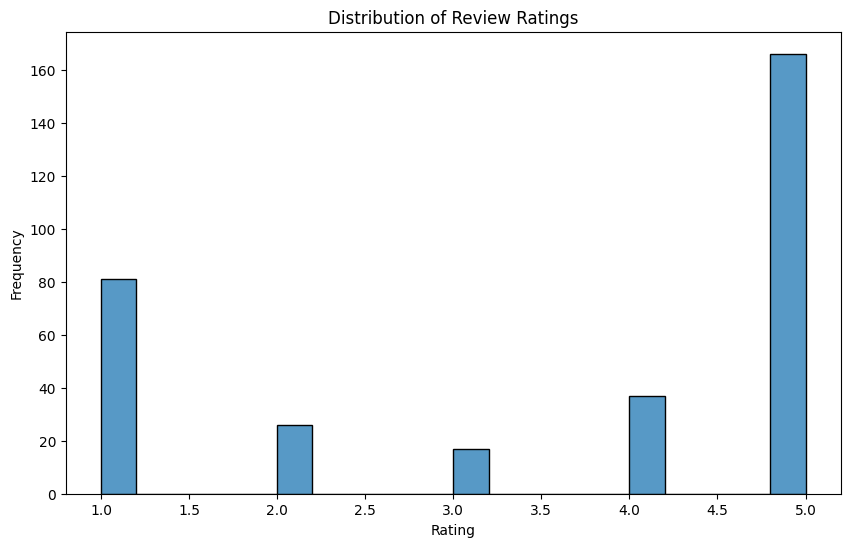

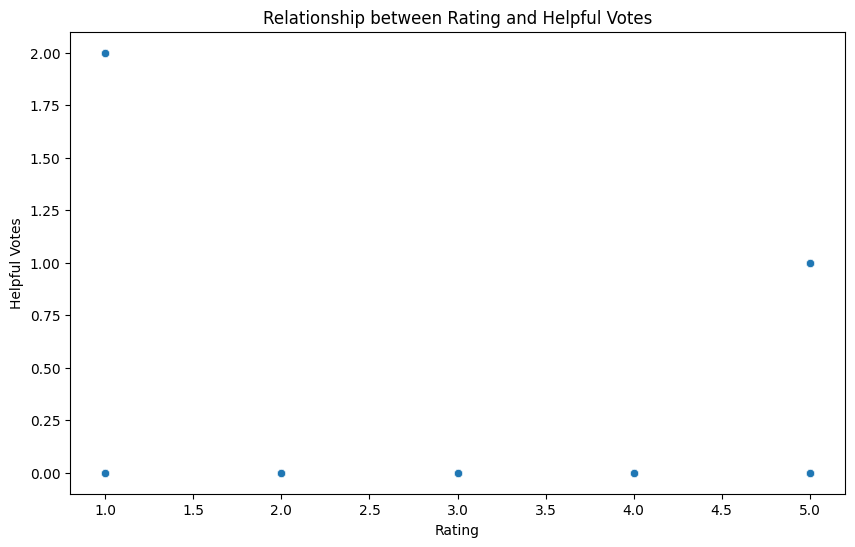

In [ ]:
reviews = pd.read_csv('E:/ProjetBI/extern_data/reviews_data.csv', sep=';')
reviews.head(20)
# Display the first few rows of the table
display(reviews.head())
# Check the data types and summary statistics of the columns
print(reviews.info())
print(reviews.describe())

# Check for missing values
print(reviews.isnull().sum())

# Visualize the distribution of review ratings
plt.figure(figsize=(10, 6))
sns.histplot(data=reviews, x='Star Rating', bins=20)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Review Ratings')
plt.show()

# Visualize the relationship between review ratings and other variables
plt.figure(figsize=(10, 6))
sns.scatterplot(data=reviews, x='Star Rating', y='Likes')
plt.xlabel('Rating')
plt.ylabel('Helpful Votes')
plt.title('Relationship between Rating and Helpful Votes')
plt.show()

In [ ]:
event = pd.read_csv('E:/ProjetBI/extern_data/events_data-2.csv', sep=';')
event.head()
# Display the first few rows of the table
display(event.head())

# Check the data types and summary statistics of the columns
print(event.info())
print(event.describe())

# Check for missing values
print(event.isnull().sum())

,Date,Year,Name,Description,Unnamed: 4
0,May 4 & May 5,2024,Silverwood Opening Day,"May 4 & May 5, 2024 - Silverwood will open its...",NaN
1,May 11 & 12,2024,Mother's Day Weekend,"May 11 & 12, 2024 - Celebrate Mother's Day at ...",NaN
2,May 18 - 19,2024,Kids Weekend,"May 18 - 19, 2024 - Celebrate Kids' Weekend at...",NaN
3,May 25,26,& 27 2024,American Heroes' Weekend,"May 25, 26, & 27 2024 - All military personnel..."
4,June 1 & 2,2024,Teacher Appreciation Weekend,"June 1 & 2, 2024 - All teachers and school per...",NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         11 non-null     object
 1   Year         10 non-null     object
 2   Name         10 non-null     object
 3   Description  10 non-null     object
 4   Unnamed: 4   1 non-null      object
dtypes: object(5)
memory usage: 568.0+ bytes
None
                 Date  Year                    Name  \
count              11    10                      10   
unique             11     4                      10   
top     May 4 & May 5  2024  Silverwood Opening Day   
freq                1     7                       1   

                                              Description  \
count                                                  10   
unique                                                 10   
top     May 4 & May 5, 2024 - Silverwood will open its...   
freq                                     

### <span style="color:red"> Disney Incidents </span>

In [ ]:
# Load the data
disney = pd.read_csv('E:/ProjetBI/extern_data/Disney-Deadly-Incidents-Total-FL_CA.csv')
disney2=pd.read_csv('E:/ProjetBI/extern_data/Disney-Deadly-Incidents-Total-FL_CA-2.csv')

merged_disney = pd.concat([disney, disney2], ignore_index=True)
# Display the first few rows of the table
display(merged_disney.head())
merged_disney.to_csv('E:/ProjetBI/extern_data/disney.csv', index=False)
# Check the data types and summary statistics of the columns
print(merged_disney.info())
print(merged_disney.describe())

# Check for missing values
print(merged_disney.isnull().sum())



,Death Caused,Death How,Date of Incident,On Attraction,Attraction Area,Location/Time,Age of Deseased,Gender of Deseased,From Where,Fault,Which State of Attraction,Age of Deceased,Gender of Deceased
0,Monorail,stuck and dragged,6/17/1966,Yes,Disneyland Park,climed onto the monorail track,19.0,Male,California,Guest Negligence,California,NaN,NaN
1,PeopleMover,crushed,8/1/1967,Yes,Disneyland Park,jumping cars,16.0,Male,California,Guest Negligence,California,NaN,NaN
2,Rivers of America,drowned,6/20/1973,Yes,Disneyland Park,Tom Sawyer's Island past closing,18.0,Male,New York,Guest Negligence,California,NaN,NaN
3,Fire,small explosion,11/4/1974,No,Magic Kingdom,boat,49.0,Male,Florida,Acts of God,Florida,NaN,NaN
4,"Main Street, U.S.A.",drowned,8/11/1977,No,Magic Kingdom,Moat surrounding Cinderella Castle,4.0,Male,Illinois,Park Negligence,Florida,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Death Caused               184 non-null    object 
 1   Death How                  184 non-null    object 
 2   Date of Incident           184 non-null    object 
 3   On Attraction              184 non-null    object 
 4   Attraction Area            184 non-null    object 
 5   Location/Time              180 non-null    object 
 6   Age of Deseased            80 non-null     float64
 7   Gender of Deseased         92 non-null     object 
 8   From Where                 184 non-null    object 
 9   Fault                      184 non-null    object 
 10  Which State of Attraction  184 non-null    object 
 11  Age of Deceased            80 non-null     float64
 12  Gender of Deceased         92 non-null     object 
dtypes: float64(2), object(11)
memory usage: 18.8+ KB
N

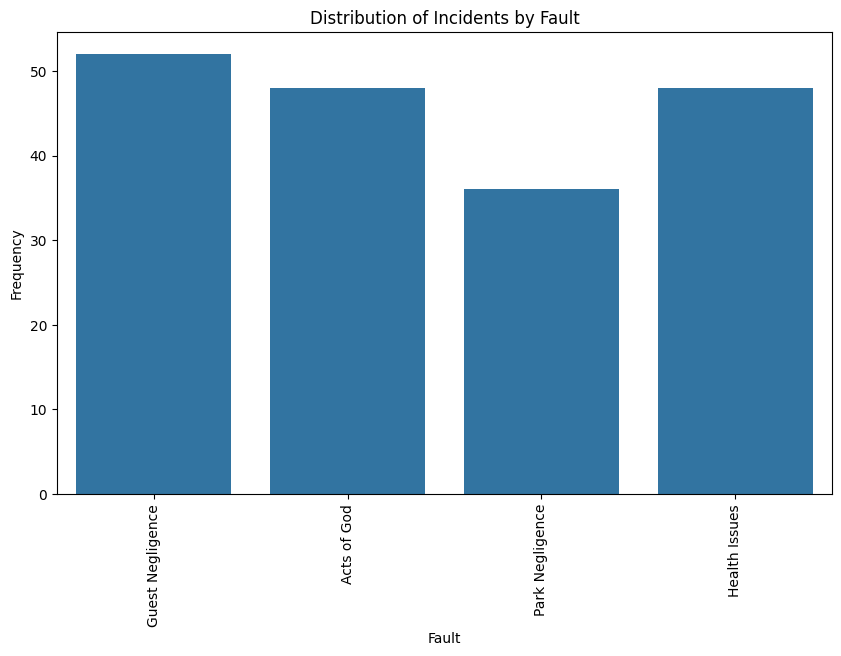

In [ ]:
# Visualize the distribution of incidents by year
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_disney, x='Fault')
plt.xlabel('Fault')
plt.ylabel('Frequency')
plt.title('Distribution of Incidents by Fault')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically
plt.show()

The bar plot provides valuable insights into the distribution of incidents by fault. From the plot, it is evident that guest negligence is the most frequent fault, while park negligence is the least common. This information highlights the importance of guest awareness and responsibility in ensuring a safe and enjoyable experience at the park.

By analyzing the distribution of incidents by fault, park management can identify areas for improvement and implement measures to mitigate risks associated with guest negligence. This proactive approach can contribute to maintaining a safe environment for visitors and enhancing overall park operations.


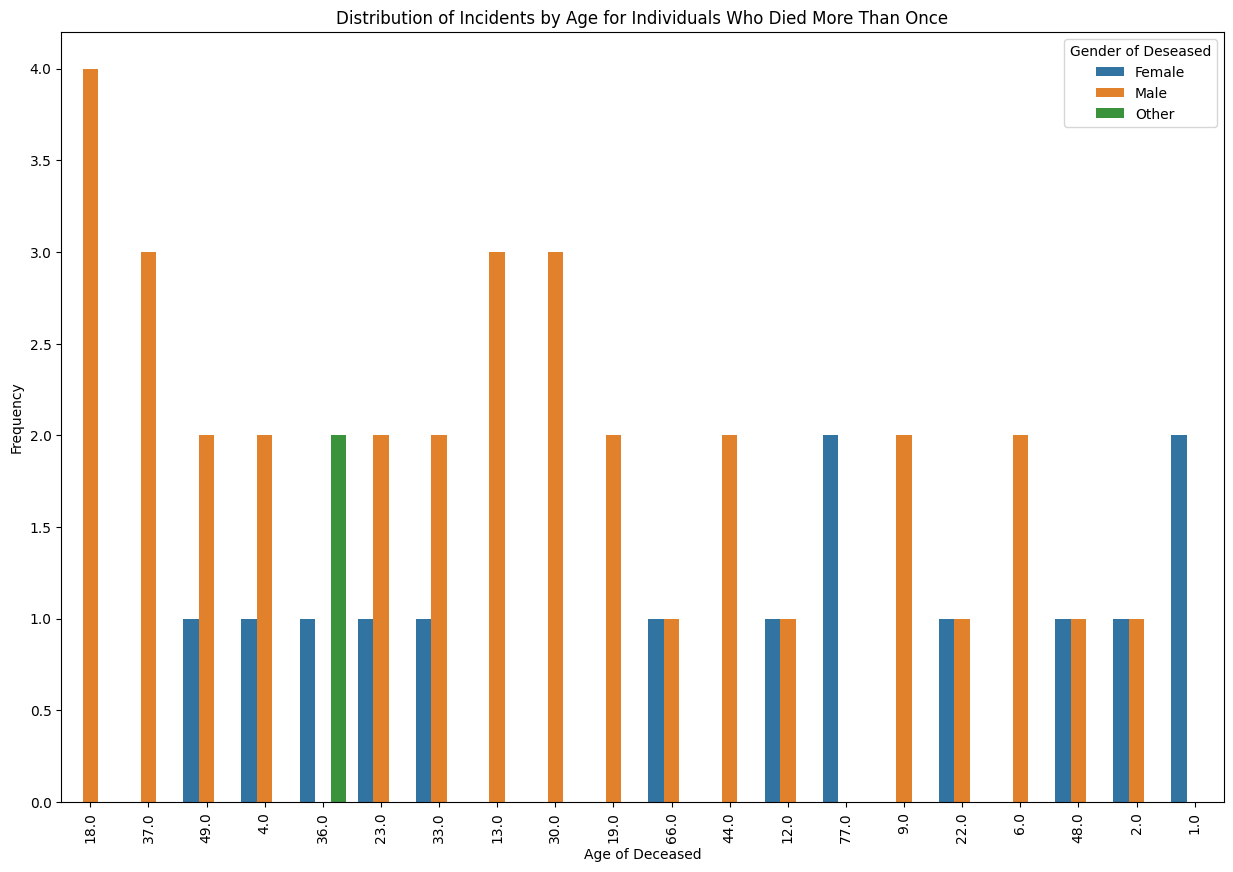

In [ ]:
# Filter the data to include only individuals who died more than once
multiple_deaths = merged_disney['Age of Deseased'].value_counts().loc[lambda x: x > 1]

# Visualize the distribution of incidents by age for individuals who died more than once
plt.figure(figsize=(15, 10))
sns.countplot(data=merged_disney, x='Age of Deseased', order=multiple_deaths.index,hue="Gender of Deseased")
plt.xlabel('Age of Deceased')
plt.ylabel('Frequency')
plt.title('Distribution of Incidents by Age for Individuals Who Died More Than Once')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically
plt.show()

The plot provides valuable insights into the distribution of ages among deceased individuals in the park. It is evident that the most common ages of deceased individuals are 18 and 37, while the number of deceased children aged 1 to 10 is relatively lower. Additionally, the data reveals that a higher number of males have experienced fatalities compared to females.

This information underscores the critical importance of prioritizing the safety and well-being of individuals across all age groups within the park. By carefully analyzing the distribution of ages among deceased individuals, park management can identify potential risks and implement appropriate measures to prevent accidents and ensure a safe environment for all visitors.

Understanding the age demographics of deceased individuals is crucial for enhancing park safety protocols and elevating the overall visitor experience. By proactively addressing potential risks and prioritizing safety measures, parks can create a secure and enjoyable environment that instills confidence and trust in their visitors.


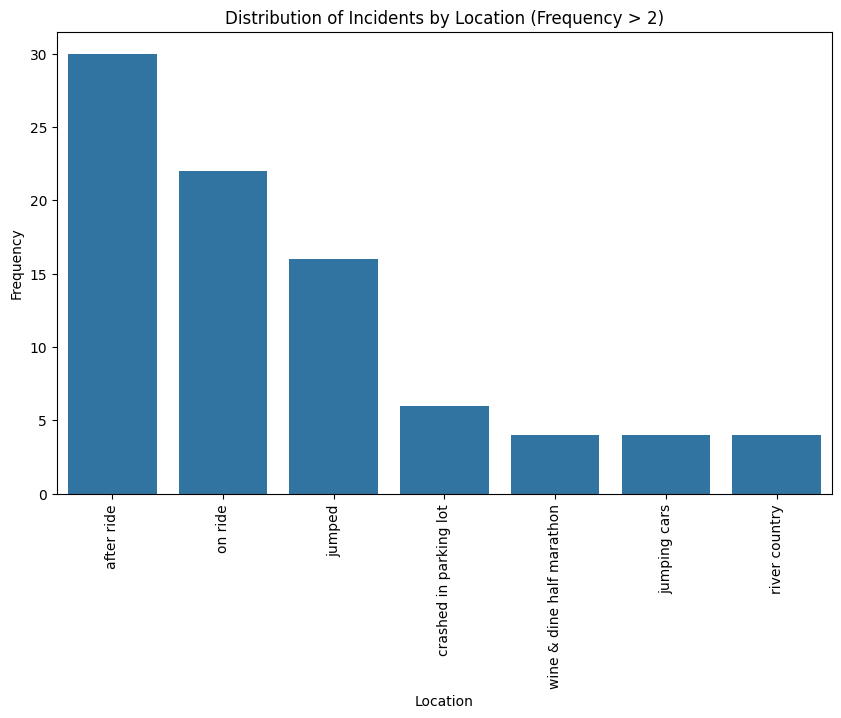

In [ ]:
# Filter the data to include only locations with a frequency greater than 2
merged_disney['Location/Time']=merged_disney['Location/Time'].str.lower()
location_counts = merged_disney['Location/Time'].value_counts().loc[lambda x: x > 2]

# Visualize the distribution of incidents by location
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_disney, x='Location/Time', order=location_counts.index)
plt.xlabel('Location')
plt.ylabel('Frequency')
plt.title('Distribution of Incidents by Location (Frequency > 2)')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically
plt.show()


The graph illustrates the distribution of incidents by location, specifically focusing on locations with a frequency greater than 2. From the analysis, it is evident that the most common location with incidents is "After Ride," followed by "On Ride." On the other hand, "River Country" has the lowest frequency of incidents.

This information provides valuable insights into the safety and risk factors associated with different locations within the park. By understanding the distribution of incidents by location, park management can prioritize safety measures and implement appropriate protocols to mitigate risks in high-frequency incident areas.

Analyzing the incident distribution by location is crucial for maintaining a safe and enjoyable environment for park visitors. By addressing potential risks and improving safety measures, parks can enhance visitor experience and ensure their well-being.


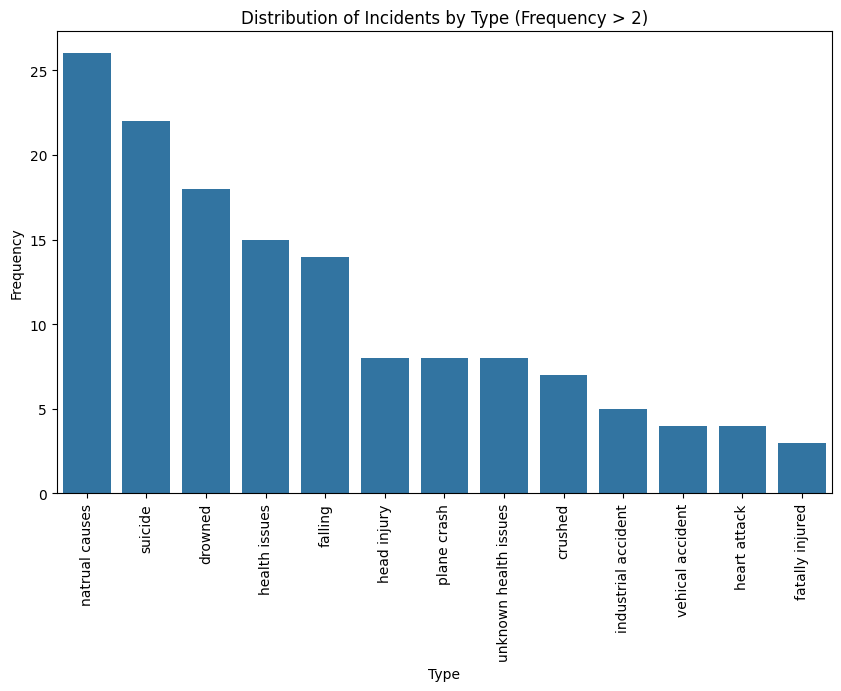

In [ ]:
# Filter the data to include only death types with a frequency greater than 2
merged_disney['Death How']=merged_disney['Death How'].str.lower()
death_counts = merged_disney['Death How'].value_counts().loc[lambda x: x > 2]

# Visualize the distribution of incidents by type
plt.figure(figsize=(10, 6))
sns.countplot(data=merged_disney, x='Death How', order=death_counts.index)
plt.xlabel('Type')
plt.ylabel('Frequency')
plt.title('Distribution of Incidents by Type (Frequency > 2)')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically
plt.show()

The distribution plot provides insights into the frequency of each incident type. From the analysis, it is evident that natural causes and suicide are the most common incident types, while fatality injured, including heart attacks, is the least frequent.

Understanding the distribution of incident types is crucial for identifying patterns and potential risks within the park. By analyzing incident frequencies, park management can prioritize safety measures and implement appropriate protocols to mitigate risks associated with the most common incident types.

This proactive approach to incident management can contribute to maintaining a safe and secure environment for park visitors, ensuring their well-being and enhancing overall park operations.
